In [ ]:
# For Exploratory Analysis
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.graphics.gofplots as sm
from scipy.stats import skew
%matplotlib inline

# For Data Preparation
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer 

# For Model Selection
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score, StratifiedShuffleSplit

# For Tuning Hyperparameters 
from sklearn.model_selection import RandomizedSearchCV,GridSearchCV
from scipy.stats import randint as sp_randInt

# For Pipeline 
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# For Model Evaluation
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy import stats 

In [ ]:
data = pd.read_csv('/content/London.csv') # importng the dataset
data # displaying the dataset

,Unnamed: 0,Property Name,Price,House Type,Area in sq ft,No. of Bedrooms,No. of Bathrooms,No. of Receptions,Location,City/County,Postal Code
0,0,Queens Road,1675000,House,2716,5,5,5,Wimbledon,London,SW19 8NY
1,1,Seward Street,650000,Flat / Apartment,814,2,2,2,Clerkenwell,London,EC1V 3PA
2,2,Hotham Road,735000,Flat / Apartment,761,2,2,2,Putney,London,SW15 1QL
3,3,Festing Road,1765000,House,1986,4,4,4,Putney,London,SW15 1LP
4,4,Spencer Walk,675000,Flat / Apartment,700,2,2,2,Putney,London,SW15 1PL
...,...,...,...,...,...,...,...,...,...,...,...
3475,3475,One Lillie Square,3350000,New development,1410,3,3,3,NaN,Lillie Square,SW6 1UE
3476,3476,St. James's Street,5275000,Flat / Apartment,1749,3,3,3,St James's,London,SW1A 1JT
3477,3477,Ingram Avenue,5995000,House,4435,6,6,6,Hampstead Garden Suburb,London,NW11 6TG
3478,3478,Cork Street,6300000,New development,1506,3,3,3,Mayfair,London,W1S 3AR


In [ ]:
data.dtypes #Display columns and their data types

Unnamed: 0            int64
Property Name        object
Price                 int64
House Type           object
Area in sq ft         int64
No. of Bedrooms       int64
No. of Bathrooms      int64
No. of Receptions     int64
Location             object
City/County          object
Postal Code          object
dtype: object

## Insights:
    - The dataset that has been imported. It consists of 3480 rows and 11 columns, which are both numerical and categorical variables.
    - The dataset contains both 6 numerical columns and 5 categorical columns out of all the 11 columns
    

In [ ]:
data.describe() # Generate descriptive statistics summary of the data: only includes numerical features

,Unnamed: 0,Price,Area in sq ft,No. of Bedrooms,No. of Bathrooms,No. of Receptions
count,3480.000000,3.480000e+03,3480.000000,3480.000000,3480.000000,3480.000000
mean,1739.500000,1.864173e+06,1712.973563,3.103736,3.103736,3.103736
std,1004.733796,2.267283e+06,1364.259351,1.517698,1.517698,1.517698
min,0.000000,1.800000e+05,274.000000,0.000000,0.000000,0.000000
25%,869.750000,7.500000e+05,834.000000,2.000000,2.000000,2.000000
50%,1739.500000,1.220000e+06,1310.000000,3.000000,3.000000,3.000000
75%,2609.250000,2.150000e+06,2157.250000,4.000000,4.000000,4.000000
max,3479.000000,3.975000e+07,15405.000000,10.000000,10.000000,10.000000


In [ ]:
data.describe(include = 'all') # Generate descriptive statistics summary of the data: includes all columns

,Unnamed: 0,Property Name,Price,House Type,Area in sq ft,No. of Bedrooms,No. of Bathrooms,No. of Receptions,Location,City/County,Postal Code
count,3480.000000,3480,3.480000e+03,3480,3480.000000,3480.000000,3480.000000,3480.000000,2518,3480,3480
unique,NaN,2380,NaN,8,NaN,NaN,NaN,NaN,656,57,2845
top,NaN,Television Centre,NaN,Flat / Apartment,NaN,NaN,NaN,NaN,Putney,London,SW6 3LF
freq,NaN,17,NaN,1565,NaN,NaN,NaN,NaN,96,2972,14
mean,1739.500000,NaN,1.864173e+06,NaN,1712.973563,3.103736,3.103736,3.103736,NaN,NaN,NaN
std,1004.733796,NaN,2.267283e+06,NaN,1364.259351,1.517698,1.517698,1.517698,NaN,NaN,NaN
min,0.000000,NaN,1.800000e+05,NaN,274.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN
25%,869.750000,NaN,7.500000e+05,NaN,834.000000,2.000000,2.000000,2.000000,NaN,NaN,NaN
50%,1739.500000,NaN,1.220000e+06,NaN,1310.000000,3.000000,3.000000,3.000000,NaN,NaN,NaN
75%,2609.250000,NaN,2.150000e+06,NaN,2157.250000,4.000000,4.000000,4.000000,NaN,NaN,NaN


In [ ]:
data.info() # prints information about the data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3480 entries, 0 to 3479
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Unnamed: 0         3480 non-null   int64 
 1   Property Name      3480 non-null   object
 2   Price              3480 non-null   int64 
 3   House Type         3480 non-null   object
 4   Area in sq ft      3480 non-null   int64 
 5   No. of Bedrooms    3480 non-null   int64 
 6   No. of Bathrooms   3480 non-null   int64 
 7   No. of Receptions  3480 non-null   int64 
 8   Location           2518 non-null   object
 9   City/County        3480 non-null   object
 10  Postal Code        3480 non-null   object
dtypes: int64(6), object(5)
memory usage: 299.2+ KB


In [ ]:
#Duplicate data, or those that have no relevance to the current situation, have been most commonly produced during data collection. Repetitive observations that support either the correct or incorrect side considerably reduce efficiency and lead to erroneous outcomes. An irrelevant observation is any form of data that is no longer important to us and could be ignored.
data.duplicated() # checks if there are any duplicate data or not 

0       False
1       False
2       False
3       False
4       False
        ...  
3475    False
3476    False
3477    False
3478    False
3479    False
Length: 3480, dtype: bool

In [ ]:
data.isnull().sum() # prints sum of null of values present in each column

Unnamed: 0             0
Property Name          0
Price                  0
House Type             0
Area in sq ft          0
No. of Bedrooms        0
No. of Bathrooms       0
No. of Receptions      0
Location             962
City/County            0
Postal Code            0
dtype: int64

We can see that the sum of null values in all the columns are zero except for the column location. We can see that the Location column consists of 962 missing entries. And as it is a categorical column, we won’t be able to use mean or median imputation. For categorical variables, we can impute the missing values by either dropping the entire column or by mode or frequency imputation. As a result, I considered dropping the entire column because we cannot use mode imputation for columns like location because if we do, the location, which has a higher frequency, will be used to replace the NaN values, causing the city, country, and postal code to be mismatched.

In [ ]:
data = data.drop('Location',axis=1) # Dropping the location column
data.head() # displaying the first 5 rows of the data

,Unnamed: 0,Property Name,Price,House Type,Area in sq ft,No. of Bedrooms,No. of Bathrooms,No. of Receptions,City/County,Postal Code
0,0,Queens Road,1675000,House,2716,5,5,5,London,SW19 8NY
1,1,Seward Street,650000,Flat / Apartment,814,2,2,2,London,EC1V 3PA
2,2,Hotham Road,735000,Flat / Apartment,761,2,2,2,London,SW15 1QL
3,3,Festing Road,1765000,House,1986,4,4,4,London,SW15 1LP
4,4,Spencer Walk,675000,Flat / Apartment,700,2,2,2,London,SW15 1PL


In [ ]:
data.isnull().sum() # checking for null values

Unnamed: 0           0
Property Name        0
Price                0
House Type           0
Area in sq ft        0
No. of Bedrooms      0
No. of Bathrooms     0
No. of Receptions    0
City/County          0
Postal Code          0
dtype: int64

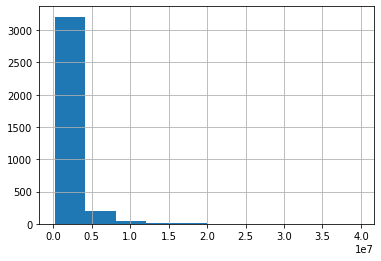

In [ ]:
data.Price.hist()
plt.show() # Histogram plot for prices features

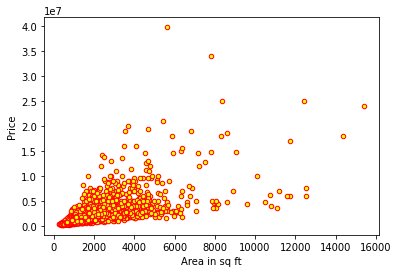

Plot-2


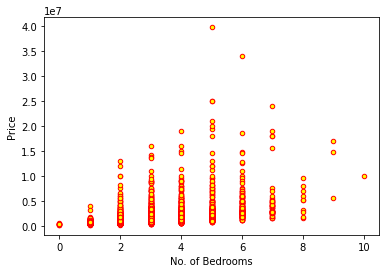

Plot-3


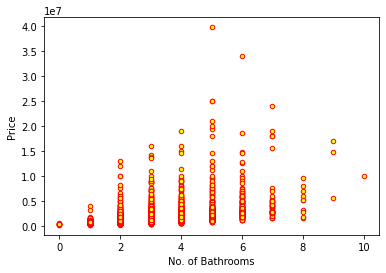

Plot-4


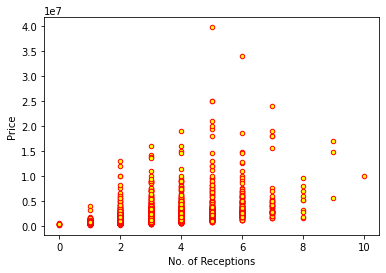

In [ ]:
# Scatter plots between the dependent column and independent columns 
data.plot.scatter(x='Area in sq ft', y='Price',c ="yellow", marker ="o",edgecolor ="red");
plt.show(block=True);# ploting scatter plot for Area in sq ft
print("Plot-2")
data.plot.scatter(x='No. of Bedrooms', y='Price',c ="yellow", marker ="o",edgecolor ="red");
plt.show(block=True);# ploting scatter plot for No. of Bedrooms
print("Plot-3")
data.plot.scatter(x='No. of Bathrooms', y='Price', c ="yellow", marker ="o",edgecolor ="red");
plt.show(block=True);# ploting scatter plot for No. of Bathrooms
print("Plot-4")
data.plot.scatter(x='No. of Receptions', y='Price', c ="yellow", marker ="o",edgecolor ="red");
plt.show(block=True);# ploting scatter plot for No. of Receptions

From the scatter plots of all the numerical variables with respect to the price variable. 
According to the area in sq ft vs. price chart, houses with a floor area of 0-4000 sq ft have a price range of 500,001-1,000,002. And the plots of No. of Bedrooms, No. of Receptions, and No. of Bathrooms vs. Price show that the houses with 5 and 6 bedrooms, bathrooms, and receptions have a higher price than other houses.

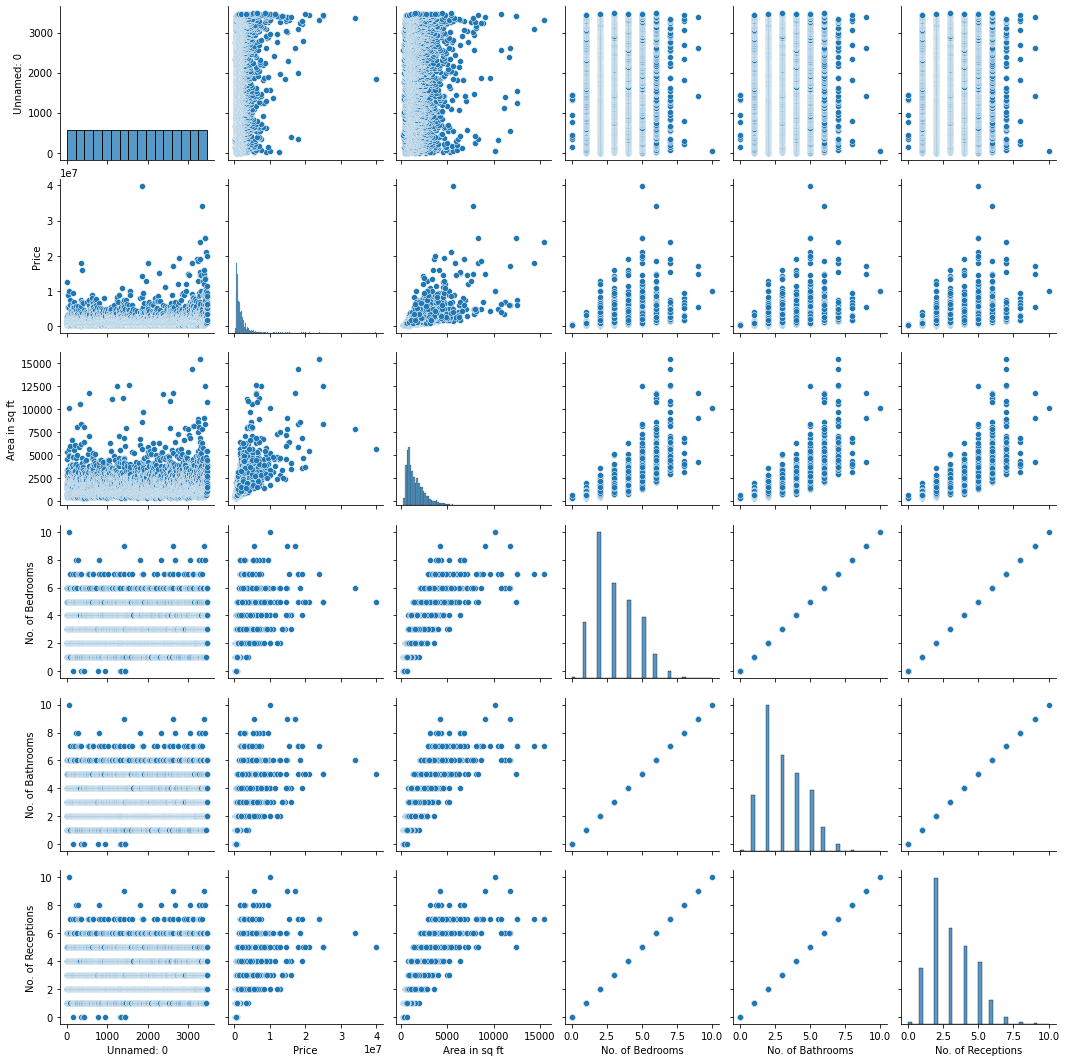

In [ ]:
sns.pairplot(data)
plt.show() # Pair plot

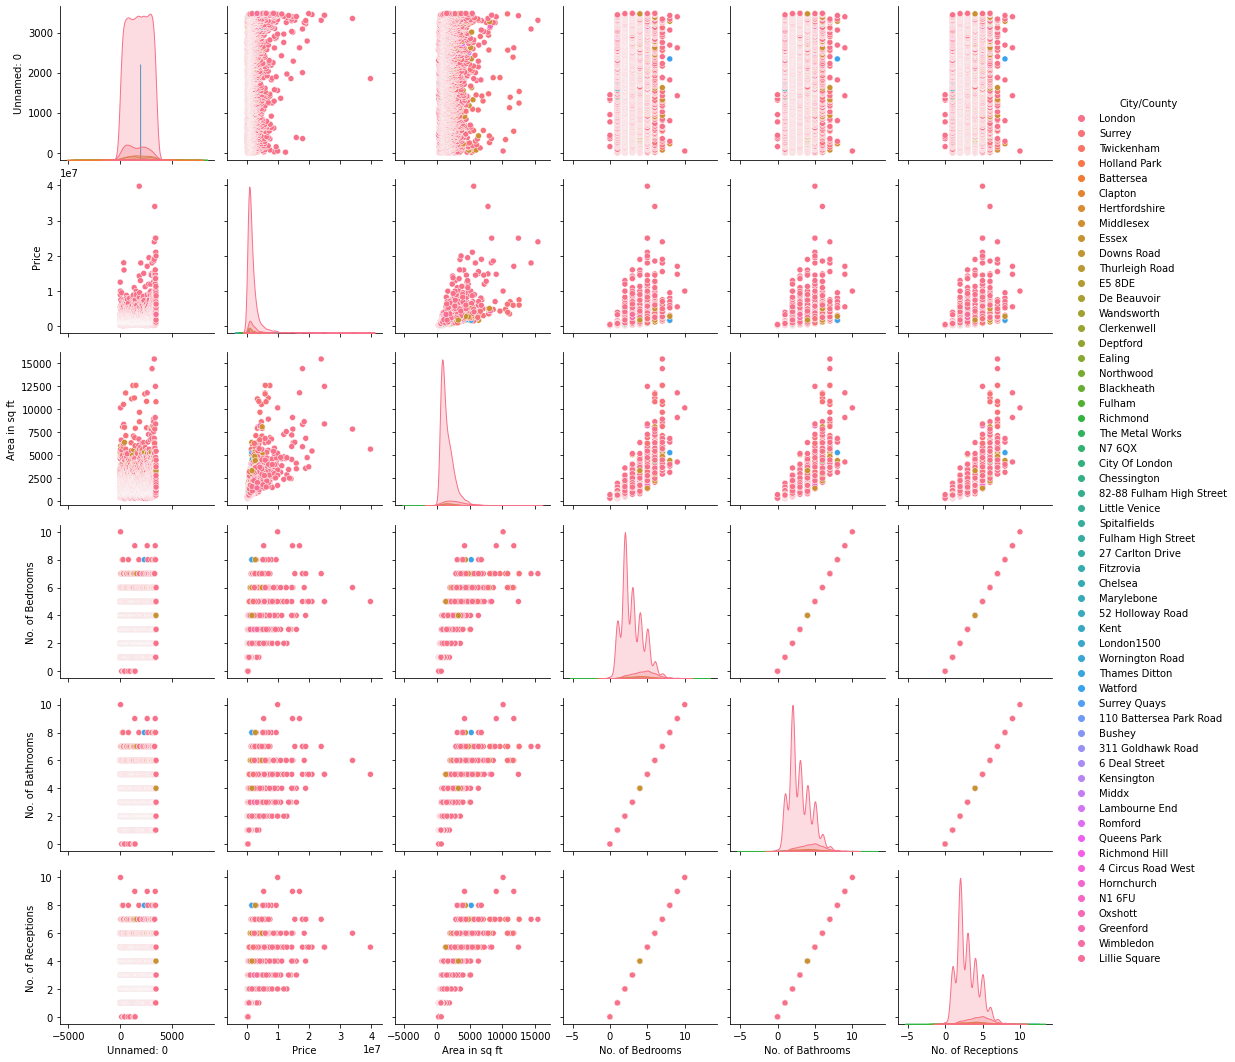

In [ ]:
sns.pairplot(data, hue = 'City/County')

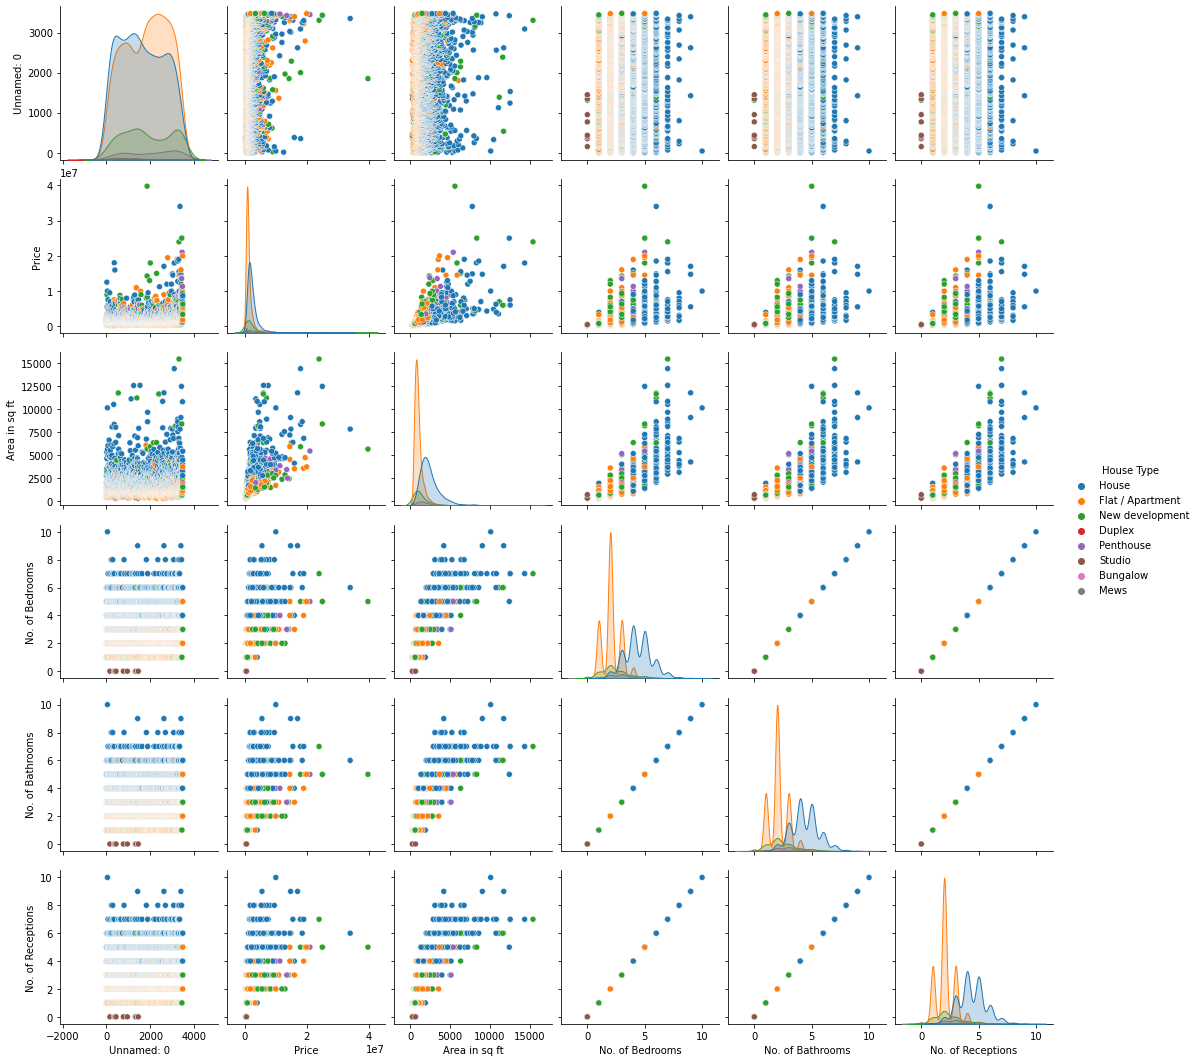

In [ ]:
sns.pairplot(data, hue = 'House Type')

## Insights:
    - Pairplot shows that "House" has the most sq ft. Most costly are homes and flats.

    

/usr/local/lib/python3.8/dist-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


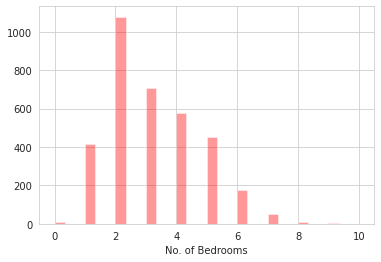

In [ ]:
#Distplot for number of bedrooms
sns.set_style('whitegrid')
sns.distplot(data['No. of Bedrooms'], kde = False, color ='red', bins = 30)

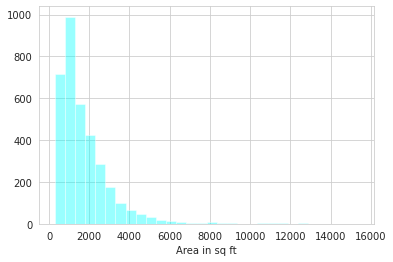

In [ ]:
#Distplot for number of Area in sq ft feature
sns.set_style('whitegrid')
sns.distplot(data['Area in sq ft'], kde = False, color ='cyan', bins = 30)

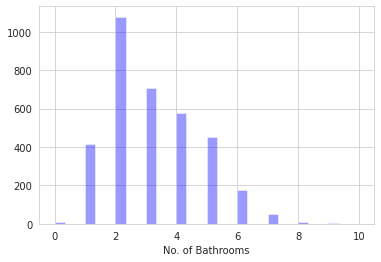

In [ ]:
#Distplot for number of bathrooms feature
sns.set_style('whitegrid')
sns.distplot(data['No. of Bathrooms'], kde = False, color ='blue', bins = 30)

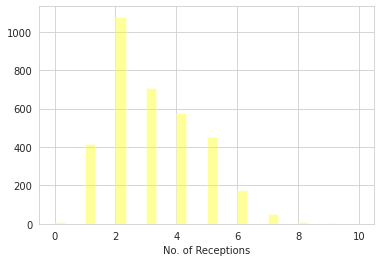

In [ ]:
#Distplot for number of receptions feature
sns.set_style('whitegrid')
sns.distplot(data['No. of Receptions'], kde = False, color ='yellow', bins = 30)

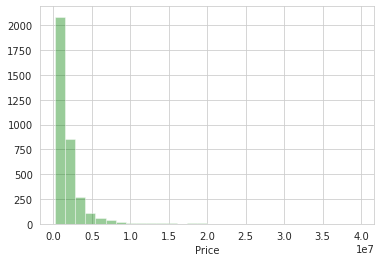

In [ ]:
#Distplot for number of price feature
sns.set_style('whitegrid')
sns.distplot(data['Price'], kde = False, color ='green', bins = 30)

From the bar plots we can see that maximum plots/houses have 2-4 bedrooms, bathrooms, and receptions. And most of the houses have an area of 0–3000 sq ft. Most of the houses have a price of less than 5000000.

/usr/local/lib/python3.8/dist-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


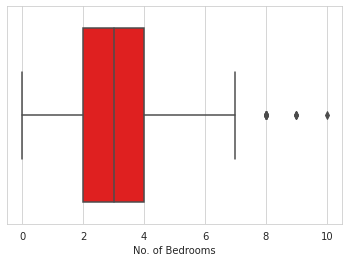

In [ ]:
#Boxplot for number of bedrooms
sns.set_style('whitegrid')
sns.boxplot(data['No. of Bedrooms'], color ='red')

/usr/local/lib/python3.8/dist-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


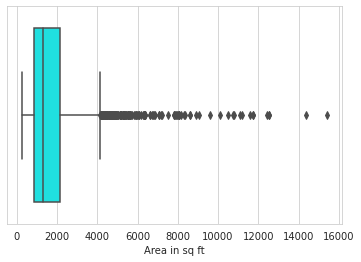

In [ ]:
#Boxplot for number of Area in sq ft
sns.set_style('whitegrid')
sns.boxplot(data['Area in sq ft'], color ='cyan')

/usr/local/lib/python3.8/dist-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


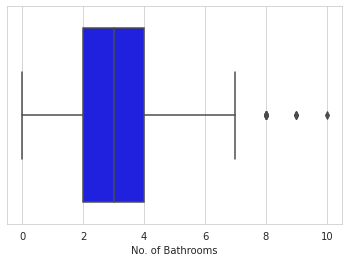

In [ ]:
#Boxplot for number of bathrooms
sns.set_style('whitegrid')
sns.boxplot(data['No. of Bathrooms'], color ='blue')

/usr/local/lib/python3.8/dist-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


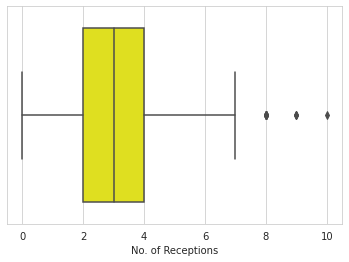

In [ ]:
#Boxplot for number of receptions
sns.set_style('whitegrid')
sns.boxplot(data['No. of Receptions'], color ='yellow')

/usr/local/lib/python3.8/dist-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


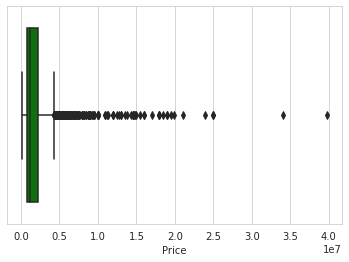

In [ ]:
#Boxplot for number of price
sns.set_style('whitegrid')
sns.boxplot(data['Price'], color ='green')

From the box plots we can see that the median value of the number of bedrooms, bathrooms, and receptions is 3. The median values for square footage and price are 1800 square feet and $200,000, respectively. The plots also show that area in square feet and price have more outliers.

0.6107728149790331

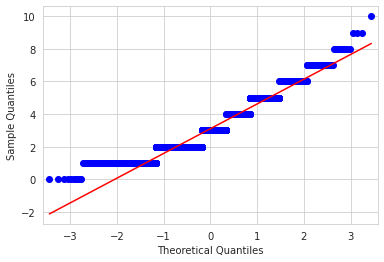

In [ ]:
#Skew value and qq plot for number of bedrooms
sm.ProbPlot(data['No. of Bedrooms']).qqplot(line='s')
skew(data['No. of Bedrooms'])

0.6107728149790331

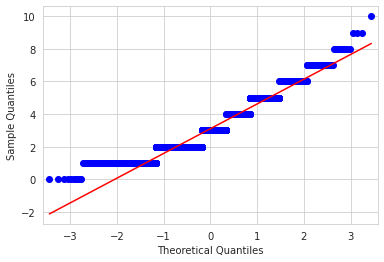

In [ ]:
#Skew value and qq plot for number of bathrooms
sm.ProbPlot(data['No. of Bathrooms']).qqplot(line='s')
skew(data['No. of Bathrooms'])

0.6107728149790331

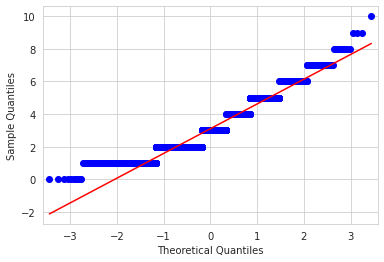

In [ ]:
#Skew value and qq plot for number of receptions
sm.ProbPlot(data['No. of Receptions']).qqplot(line='s')
skew(data['No. of Receptions'])

5.770156996988357

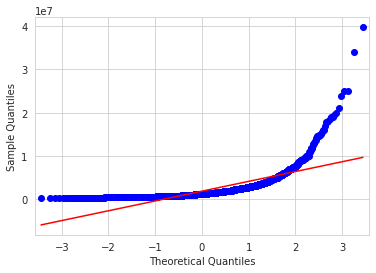

In [ ]:
#Skew value and qq plot for price
sm.ProbPlot(data['Price']).qqplot(line='s')
skew(data['Price'])

3.111337414841114

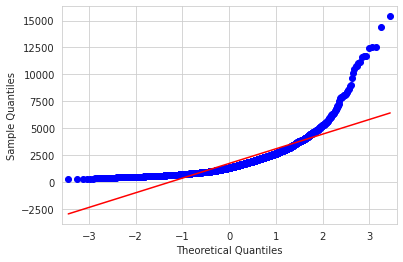

In [ ]:
#Skew value and qq plot for Area in sq ft
sm.ProbPlot(data['Area in sq ft']).qqplot(line='s')
skew(data['Area in sq ft'])

## Insights:
No. of bathrooms, No. of bedrooms, and No. of receptions have the same skew value, i.e., 0.61, and from the skew value we can say that these columns or variables are moderately skewed. But the skew values of area in square feet and prices are greater than 1, and we can say that these columns are highly skewed.

In [ ]:
numeric_data = data.select_dtypes(include=[np.number]) # Checking the numerical feature present in the data
categorical_data = data.select_dtypes(exclude=[np.number]) # checking the categorical features present in the data

numeric_data.shape[1] # Printing the number of numeric features present

6

In [ ]:
categorical_data.shape[1] # Printing the number of categorical features present

4

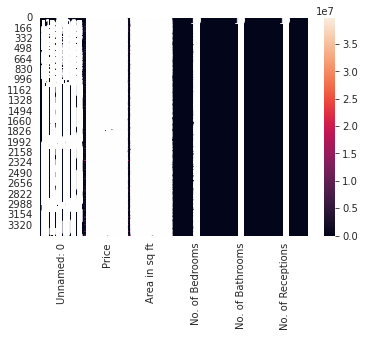

In [ ]:
sns.heatmap(numeric_data, annot=True) # Heatmap

In [ ]:
X = data['Property Name'].value_counts() # Checking for the number of unique values count in the property name feature
Y = data['House Type'].value_counts() # Checking for the number of unique values count in the house type feature
B = data['City/County'].value_counts() # Checking for the number of unique values count in the city/county feature
C = data['Postal Code'].value_counts() # Checking for the number of unique values count in the posstal code feature
print(X)
print(Y)
print(B)
print(C)

Television Centre    17
City Road            14
Bishops Gate         14
Eaton Square         11
Junction House        8
                     ..
Norfolk Mansions      1
Springfield Road      1
Liberty House         1
Ravens Close          1
One Lillie Square     1
Name: Property Name, Length: 2380, dtype: int64
Flat / Apartment    1565
House               1430
New development      357
Penthouse            100
Studio                10
Bungalow               9
Duplex                 7
Mews                   2
Name: House Type, dtype: int64
London                      2972
Surrey                       262
Middlesex                     78
Essex                         62
Twickenham                    12
Hertfordshire                  9
Thurleigh Road                 7
N7 6QX                         7
Fulham                         5
Wornington Road                5
Watford                        4
Marylebone                     4
Chelsea                        3
City Of London              

In [ ]:
# Import label encoder
from sklearn import preprocessing
# label_encoder object knows how to understand word labels.
label_encoder = preprocessing.LabelEncoder()

In [ ]:
data['Property Name']= label_encoder.fit_transform(data['Property Name']) # Label encoding property name feature
data['Property Name'].unique()  # printing unique values present in property name 

array([1739, 1888, 1147, ...,  447, 1731, 1564])

In [ ]:
n = len(pd.unique(data['Property Name']))
print("No.of.unique values :",  n) # checking number of unique values present in the property name

No.of.unique values : 2380


In [ ]:
data['House Type']= label_encoder.fit_transform(data['House Type']) # Label encoding house type feature
data['House Type'].unique() # printing unique values present in the house type

array([3, 2, 5, 1, 6, 7, 0, 4])

In [ ]:
n = len(pd.unique(data['House Type']))
print("No.of.unique values :",  n) # checking number of unique values present in the house type

No.of.unique values : 8


In [ ]:
data['City/County']= label_encoder.fit_transform(data['City/County']) # Label encoding city/county feature
data['City/County'].unique() # printing unique values present in city/county

array([33, 47, 52, 26,  7, 13, 25, 36, 20, 17, 51, 18, 15, 53, 14, 16, 19,
       40,  8, 22, 43, 50, 39, 12, 11,  6, 32, 46, 23,  1, 21, 10, 35,  4,
       29, 34, 56, 49, 54, 48,  0,  9,  2,  5, 28, 37, 30, 45, 42, 44,  3,
       27, 38, 41, 24, 55, 31])

In [ ]:
n = len(pd.unique(data['City/County']))
print("No.of.unique values :",  n) # checking number of unique values present in city/county

No.of.unique values : 57


In [ ]:
data['Postal Code']= label_encoder.fit_transform(data['Postal Code']) # Label encoding postal code feature
data['Postal Code'].unique() # printing unique values present in postal code

array([1776,  291, 1448, ...,  817, 2489,  732])

In [ ]:
n = len(pd.unique(data['Postal Code']))
print("No.of.unique values :",  n)  # checking number of unique values present in postal code

No.of.unique values : 2845


In [ ]:
Data =data 

In [ ]:
Final_Data = Data.drop(labels=['Unnamed: 0','No. of Bathrooms',	'No. of Receptions'], axis=1) # Dropping unwanted columns
Final_Data

,Property Name,Price,House Type,Area in sq ft,No. of Bedrooms,City/County,Postal Code
0,1739,1675000,3,2716,5,33,1776
1,1888,650000,2,814,2,33,291
2,1147,735000,2,761,2,33,1448
3,850,1765000,3,1986,4,33,1438
4,1945,675000,2,700,2,33,1442
...,...,...,...,...,...,...,...
3475,1564,3350000,5,1410,3,31,2096
3476,1981,5275000,2,1749,3,33,1786
3477,1172,5995000,3,4435,6,33,817
3478,588,6300000,5,1506,3,33,2489


In [ ]:
X= Final_Data.drop('Price', axis=1) 
y= Final_Data['Price'].copy()

In [ ]:
from sklearn.model_selection import train_test_split # Splitting the data into train and test datasets
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.33, random_state=42)

In [ ]:
# Printing the shapes of the training and testing data
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(2331, 6)
(2331,)
(1149, 6)
(1149,)


In [ ]:
m = list(X_train.columns) # feature names present in X_train data
m 

['Property Name',
 'House Type',
 'Area in sq ft',
 'No. of Bedrooms',
 'City/County',
 'Postal Code']

In [ ]:
! pip install shap # installing shap library

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 575 kB 6.0 MB/s 


In [ ]:
# XgBoost Model training using keras
import xgboost as xgb
from xgboost import XGBRegressor
My_model = XGBRegressor() # Importing the xgboost regressor
xgb_mod=My_model.fit(X_train, y_train, verbose=False) # Fitting the train data into the already imported xgboost regressor

[01:30:27] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.


In [ ]:
# Usage of shap library for checking the important features
import shap
explainer = shap.Explainer(My_model,X_train) # explaining the prediction of xgboost model by computing the contribution of each feature to the prediction.
shap_values = explainer.shap_values(X_train) # shap values are used to break down a prediction to show the impact of each feature (i.e,  interpret the impact of having a certain value for a given feature in comparison to the prediction)
expected_value = explainer.expected_value 

In [ ]:
# Shap values 
shap_values

array([[-1.33388703e+03,  2.18411353e+04, -7.63879940e+05,
         1.42883466e+05,  1.44144302e+05, -3.58785101e+05],
       [ 5.94839984e+03,  6.13279696e+04, -1.32529682e+05,
         1.46259920e+05,  1.49659528e+05, -4.27302108e+05],
       [ 5.37605394e+03, -2.34590733e+05,  6.85141463e+05,
        -2.99980283e+05,  1.49727628e+05, -4.41966114e+05],
       ...,
       [-1.33388703e+03,  5.93089375e+03,  3.28965619e+05,
        -4.30931832e+04,  1.41069694e+05,  3.03341571e+05],
       [ 1.92991227e+04,  2.97204247e+05, -4.28866494e+05,
         7.54259961e+01,  1.54107739e+05, -1.76089029e+05],
       [ 7.84728066e+03,  3.63025936e+04, -6.06322424e+05,
         1.34455923e+05,  1.48243641e+05, -1.21820119e+05]])

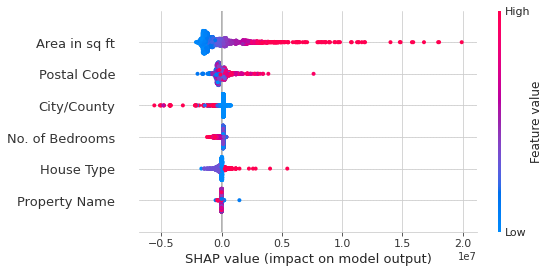

In [ ]:
# Generate summary dot plot
shap.summary_plot(shap_values, X_train,title="SHAP summary plot") 

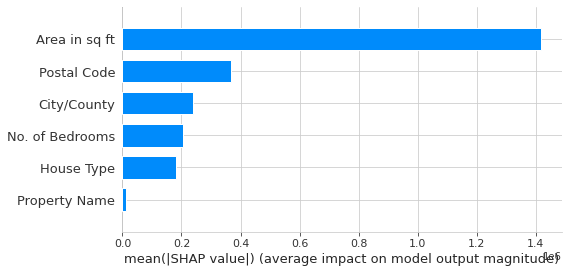

In [ ]:
# Generate summary bar plot 
shap.summary_plot(shap_values, X_train ,plot_type="bar")

From the shap summary plot we can observe that the features " area in sq ft," "postal code," "city/county," and "number of bedrooms" contribute more towards the output than the house type and property name. In the bar plot/mean shap plot, we determine the average absolute of the shap value over all occurrences. The dot summary plot illustrates how well the feature value grows with an increase in shap values. Since we don't want positive and negative values to cancel each other out, we shall take the absolute values

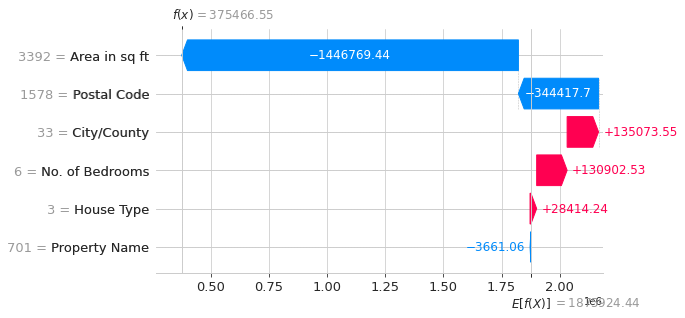

In [ ]:
# Generate waterfall plot 
shap.initjs(), 
shap.plots._waterfall.waterfall_legacy(expected_value, shap_values[10], features=X_train.loc[10,:], feature_names=X_train.columns, max_display=7, show=True)

PInsights of shap waterfall plot: Positive shap values are understood to mean that the log odds are improving. For instance, the log odds increased by 155383.02 for the number of bedrooms. And negative shap values are understood to mean that the log odds are decreasing. For instance, the log-odds decreased by 1457178.88 for area in sq ft.

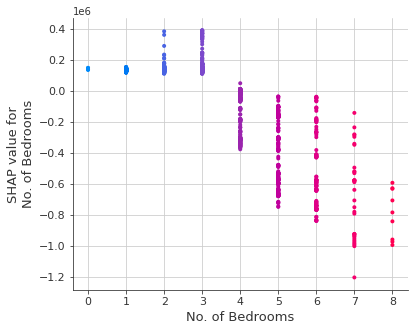

In [ ]:
# Generate dependence plot
shap.initjs(),
shap.dependence_plot("No. of Bedrooms", shap_values, X_train, interaction_index="No. of Bedrooms")

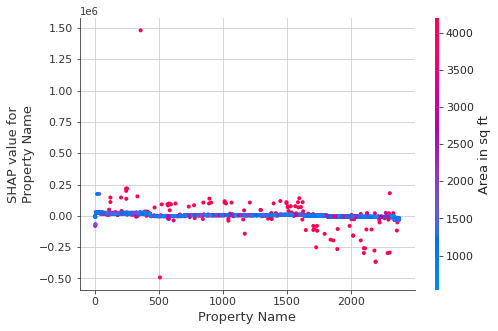

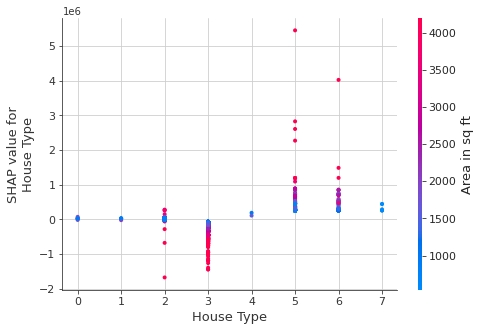

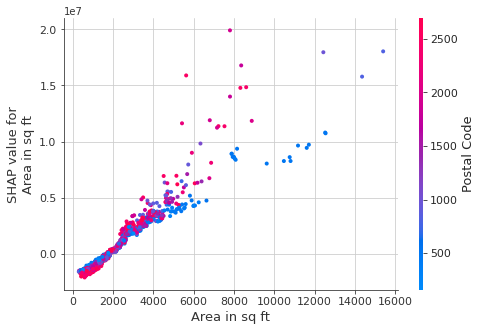

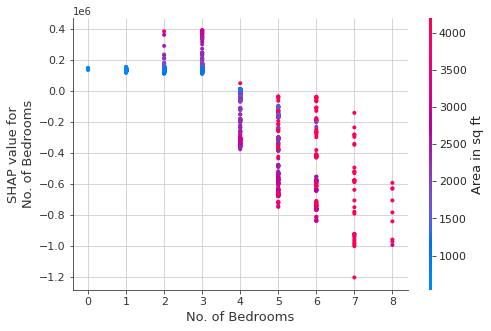

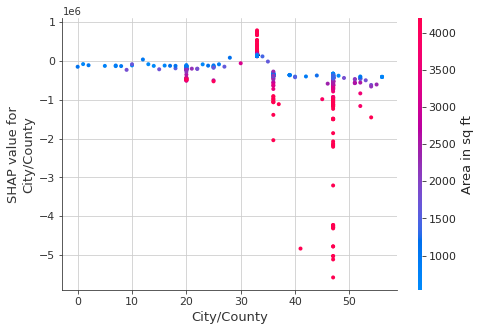

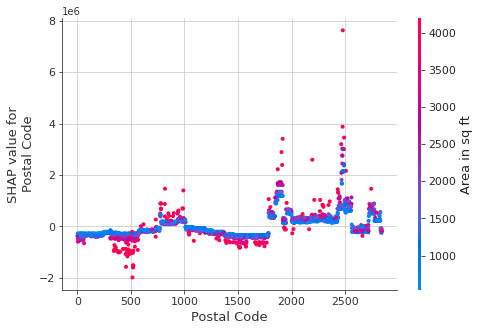

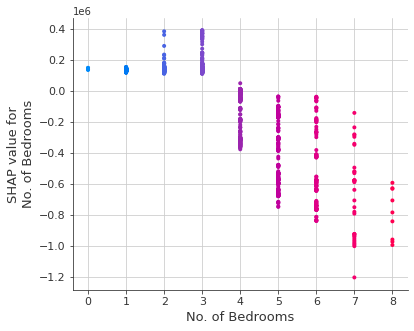

In [ ]:
# Generate multiple dependence plots
for name in X_train.columns:
     shap.dependence_plot(name, shap_values, X_train)
shap.dependence_plot("No. of Bedrooms", shap_values, X_train, interaction_index="No. of Bedrooms")

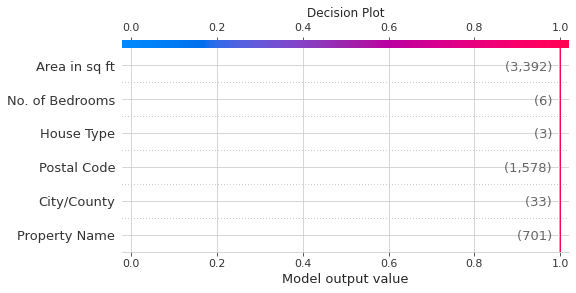

In [ ]:
# Generate Decision plot 
shap.initjs(),
shap.decision_plot(expected_value, shap_values[50],link='logit' ,features=X_train.loc[10,:], feature_names=(X_train.columns.tolist()),show=True,title="Decision Plot")

In [ ]:
final_predictions = My_model.predict(X_test) # From the already trained model we will be predicting the house prices for testing data
forest_test_rmse = mean_squared_error(y_test, final_predictions, squared=False) # Calculating the rmse value of the predictions
print('Testing RMSE:', round(forest_test_rmse, 2))

Testing RMSE: 1062713.35


Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.


Text(0.5, 1.0, 'Residual plot for XgBoost')

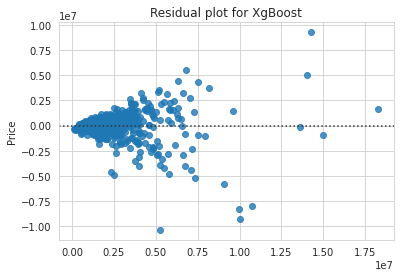

In [ ]:
# Residual Plot for XgBoost Model
from seaborn.regression import residplot
sns.residplot(final_predictions, (final_predictions - y_test)) 
plt.title('Residual plot for XgBoost')

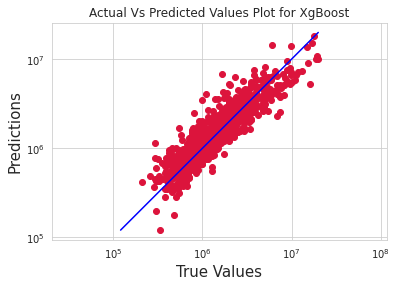

In [ ]:
# Actual vs Predicted Plot for XgBoost
plt.scatter(y_test, final_predictions, c='crimson')
plt.yscale('log')
plt.xscale('log')

p1 = max(max(final_predictions), max(y_test))
p2 = min(min(final_predictions), min(y_test))
plt.plot([p1, p2], [p1, p2], 'b-')
plt.xlabel('True Values', fontsize=15)
plt.ylabel('Predictions', fontsize=15)
plt.axis('equal')
plt.title("Actual Vs Predicted Values Plot for XgBoost")
plt.show()

In [ ]:
# R2 score for XgBoost 
from sklearn.metrics import r2_score
r2_score(y_test, final_predictions)

0.7441195369509988

In [ ]:
# Mean Absolute error for XgBoost
from sklearn.metrics import mean_absolute_error
mean_absolute_error(y_test, final_predictions)

507405.7585400348

In [ ]:
# Mean squared error for XgBooost
from sklearn.metrics import mean_squared_error
mean_squared_error(y_test, final_predictions)

1129359661700.3696

### Linear Regression

In [ ]:
# creating a Linear Regression Instance and fitting
lin_reg=LinearRegression()
lin_reg.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Root Mean Squared error for Linear Regression
final_predictions1 = lin_reg.predict(X_test)
rmse = mean_squared_error(y_test, final_predictions1, squared=False)
print('Testing RMSE:', round(rmse, 2))

Testing RMSE: 1483742.48


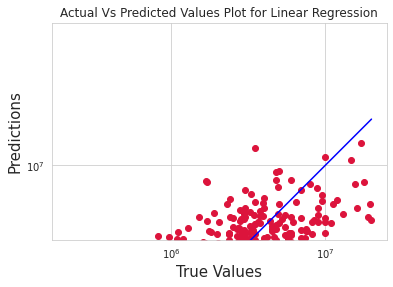

In [ ]:
# Actual vs Predicted Plot for Linear Regression
plt.scatter(y_test, final_predictions1, c='crimson')
plt.yscale('log')
plt.xscale('log')

p1 = max(max(final_predictions1), max(y_test))
p2 = min(min(final_predictions1), min(y_test))
plt.plot([p1, p2], [p1, p2], 'b-')
plt.xlabel('True Values', fontsize=15)
plt.ylabel('Predictions', fontsize=15)
plt.axis('equal')
plt.title("Actual Vs Predicted Values Plot for Linear Regression")
plt.show()

Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.


Text(0.5, 1.0, 'Residual plot for Linear Regression')

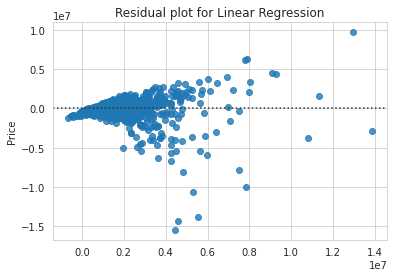

In [ ]:
# Residual Plot for Linear Regression
sns.residplot(final_predictions1, (final_predictions1 - y_test))
plt.title('Residual plot for Linear Regression')

In [ ]:
# R2 score for Linear Regression
r2_score(y_test, final_predictions1)

0.5012052000925822

In [ ]:
# Mean Absolute error for Linear Regression
mean_absolute_error(y_test, final_predictions1)

788490.8711424975

In [ ]:
# Mean squared error for Linear Regression
mean_squared_error(y_test, final_predictions1)

2201491742546.476

### Ridge Regression

In [ ]:
# Importimg Ridge from sklearn linear model
# creating a Ridge Regression Instance and fitting
from sklearn.linear_model import Ridge
clf = Ridge(alpha=1.0)
clf.fit(X_train, y_train)

Ridge()

In [ ]:
# Root Mean Squared error for Ridge
final_predictions2 = clf.predict(X_test)
rmse1 = mean_squared_error(y_test, final_predictions2, squared=False)
print('Testing RMSE:', round(rmse1, 2))

Testing RMSE: 1483736.52


In [ ]:
# R2 score for Ridge Regression
r2_score(y_test, final_predictions2)

0.5012092035628686

In [ ]:
# Mean Absolute error for Ridge Regression
mean_absolute_error(y_test, final_predictions2)

788472.3932924237

In [ ]:
# Mean squared error for Ridge Regression
mean_squared_error(y_test, final_predictions2)

2201474072741.6216

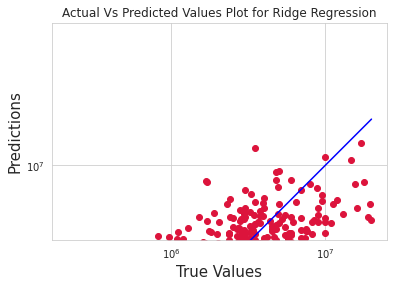

In [ ]:
# Actual vs Predicted Plot for Ridge Regression
plt.scatter(y_test, final_predictions2, c='crimson')
plt.yscale('log')
plt.xscale('log')

p1 = max(max(final_predictions2), max(y_test))
p2 = min(min(final_predictions2), min(y_test))
plt.plot([p1, p2], [p1, p2], 'b-')
plt.xlabel('True Values', fontsize=15)
plt.ylabel('Predictions', fontsize=15)
plt.axis('equal')
plt.title("Actual Vs Predicted Values Plot for Ridge Regression")
plt.show()

Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.


Text(0.5, 1.0, 'Residual plot for Ridge Regression')

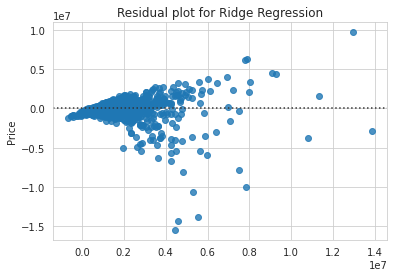

In [ ]:
# Residual Plot for Ridge Regression
sns.residplot(final_predictions2, (final_predictions2 - y_test))
plt.title('Residual plot for Ridge Regression')

### Lasso Regression

In [ ]:
# Importimg linear model from sklearn linear model
# creating a Lasso Regression Instance and fitting
from sklearn import linear_model
clf = linear_model.Lasso(alpha=0.1)
clf.fit(X_train, y_train)

Lasso(alpha=0.1)

In [ ]:
print(clf.coef_)# Printing coefficients of model

[-4.76210943e+01  1.73472453e+05  1.42560982e+03 -3.49122321e+05
 -6.08323603e+04  4.86516848e+02]


In [ ]:
print(clf.intercept_)# Printing intercept of model

1439727.915989623


In [ ]:
# Root Mean Squared error for Lasso
final_predictions2 = clf.predict(X_test)
rmse1 = mean_squared_error(y_test, final_predictions2, squared=False)
print('Testing RMSE:', round(rmse1, 2))

Testing RMSE: 1483742.47


In [ ]:
# R2 score for Lasso Regression
r2_score(y_test, final_predictions2)

0.5012052056544096

In [ ]:
# Mean Absolute error for Lasso Regression
mean_absolute_error(y_test, final_predictions2)

788490.847371198

In [ ]:
# Mean squared error for Lasso Regression
mean_squared_error(y_test, final_predictions2)

2201491717998.672

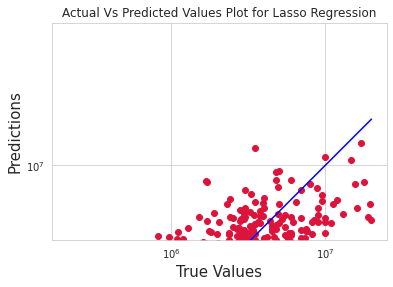

In [ ]:
# Actual vs Predicted Plot for Ridge Regression
plt.scatter(y_test, final_predictions2, c='crimson')
plt.yscale('log')
plt.xscale('log')

p1 = max(max(final_predictions2), max(y_test))
p2 = min(min(final_predictions2), min(y_test))
plt.plot([p1, p2], [p1, p2], 'b-')
plt.xlabel('True Values', fontsize=15)
plt.ylabel('Predictions', fontsize=15)
plt.axis('equal')
plt.title("Actual Vs Predicted Values Plot for Lasso Regression")
plt.show()

Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.


Text(0.5, 1.0, 'Residual plot for Lasso Regression')

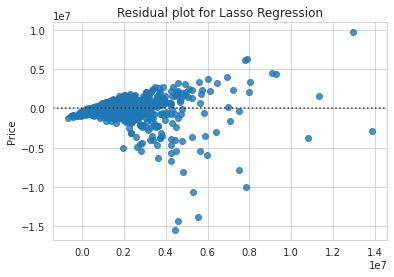

In [ ]:
# Residual Plot for Ridge Regression
sns.residplot(final_predictions2, (final_predictions2 - y_test))
plt.title('Residual plot for Lasso Regression')

### Logistic Regression

In [ ]:
# Importimg LogisticRegression from sklearn linear model
# creating a Logistic Regression Instance and fitting
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression(random_state=0).fit(X_train, y_train)

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression


In [ ]:
clf.predict(X_test)# printing predicted values 

array([ 550000,  625000, 1350000, ..., 2500000, 1350000, 2500000])

In [ ]:
# Root Mean Squared error for Logistic Regression
final_predictions2 = clf.predict(X_test)
rmse1 = mean_squared_error(y_test, final_predictions2, squared=False)
print('Testing RMSE:', round(rmse1, 2))

Testing RMSE: 2715544.96


In [ ]:
# R2 score for Logistic Regression
r2_score(y_test, final_predictions2)

-0.6707784015589189

In [ ]:
# Mean Absolute error for Logistic Regression
mean_absolute_error(y_test, final_predictions2)

1174015.5892080069

In [ ]:
# Mean squared error for Logistic Regression
mean_squared_error(y_test, final_predictions2)

7374184444865.26

Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.


Text(0.5, 1.0, 'Residual plot for Logistic Regression')

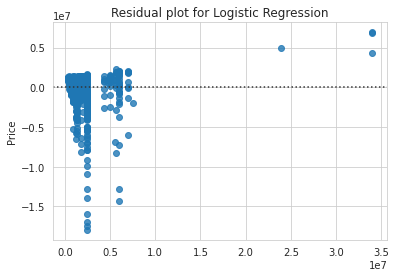

In [ ]:
# Residual Plot for Logistic Regression
sns.residplot(final_predictions2, (final_predictions2 - y_test))
plt.title('Residual plot for Logistic Regression')

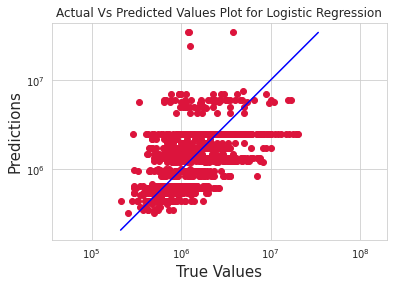

In [ ]:
# Actual vs Predicted Plot for Logistic Regression
plt.scatter(y_test, final_predictions2, c='crimson')
plt.yscale('log')
plt.xscale('log')

p1 = max(max(final_predictions2), max(y_test))
p2 = min(min(final_predictions2), min(y_test))
plt.plot([p1, p2], [p1, p2], 'b-')
plt.xlabel('True Values', fontsize=15)
plt.ylabel('Predictions', fontsize=15)
plt.axis('equal')
plt.title("Actual Vs Predicted Values Plot for Logistic Regression")
plt.show()

### Decision Tree Classifier

In [ ]:
# Importimg DecisionTreeClassifier from sklearn.tree
# creating a DecisionTreeClassifier Instance and fitting
from sklearn.tree import DecisionTreeClassifier
clf = DecisionTreeClassifier(random_state=0).fit(X_train, y_train)

In [ ]:
# Root Mean Squared error for DecisionTreeClassifier
final_predictions2 = clf.predict(X_test)
rmse1 = mean_squared_error(y_test, final_predictions2, squared=False)
print('Testing RMSE:', round(rmse1, 2))

Testing RMSE: 1660104.79


In [ ]:
# R2 score for DecisionTreeClassifier
r2_score(y_test, final_predictions2)

0.3755813581635402

In [ ]:
# Mean Absolute error for DecisionTreeClassifier
mean_absolute_error(y_test, final_predictions2)

736594.0696257615

In [ ]:
# Mean squared error for DecisionTreeClassifier
mean_squared_error(y_test, final_predictions2)

2755947905130.9346

Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.


Text(0.5, 1.0, 'Residual plot for Decision Tree')

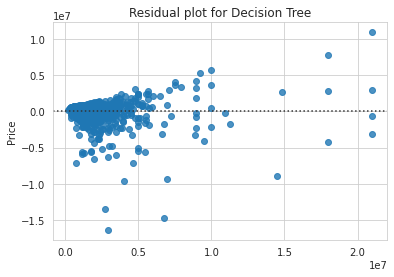

In [ ]:
# Residual Plot for DecisionTreeClassifier
sns.residplot(final_predictions2, (final_predictions2 - y_test))
plt.title('Residual plot for Decision Tree')

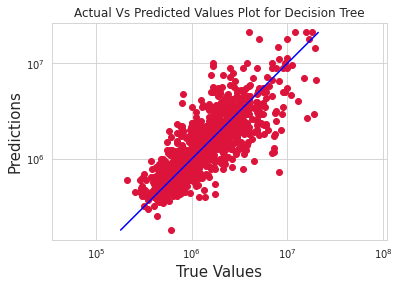

In [ ]:
# Actual vs Predicted Plot for DecisionTreeClassifier
plt.scatter(y_test, final_predictions2, c='crimson')
plt.yscale('log')
plt.xscale('log')

p1 = max(max(final_predictions2), max(y_test))
p2 = min(min(final_predictions2), min(y_test))
plt.plot([p1, p2], [p1, p2], 'b-')
plt.xlabel('True Values', fontsize=15)
plt.ylabel('Predictions', fontsize=15)
plt.axis('equal')
plt.title("Actual Vs Predicted Values Plot for Decision Tree")
plt.show()

### Random Forest

In [ ]:
# Importimg RandomForestClassifier from sklearn.ensemble
# creating a RandomForestClassifier Instance and fitting
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(max_depth=2, random_state=0).fit(X_train, y_train)

In [ ]:
# Root Mean Squared error for RandomForest
final_predictions2 = clf.predict(X_test)
rmse1 = mean_squared_error(y_test, final_predictions2, squared=False)
print('Testing RMSE:', round(rmse1, 2))

Testing RMSE: 1876443.18


In [ ]:
print(r2_score(y_test, final_predictions2))# R2 score for RandomForest
print(mean_absolute_error(y_test, final_predictions2))# Mean Absolute error for RandomForest
print(mean_squared_error(y_test, final_predictions2))# Mean squared error for RandomForest

0.2022336869436122
835203.5805047868
3521039014443.154


Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.


Text(0.5, 1.0, 'Residual plot for Random Forest')

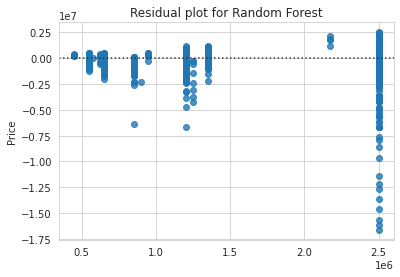

In [ ]:
# Residual Plot for RandomForest
sns.residplot(final_predictions2, (final_predictions2 - y_test))
plt.title('Residual plot for Random Forest')

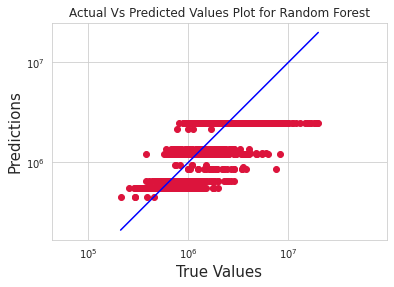

In [ ]:
# Actual vs Predicted Plot for RandomForest
plt.scatter(y_test, final_predictions2, c='crimson')
plt.yscale('log')
plt.xscale('log')

p1 = max(max(final_predictions2), max(y_test))
p2 = min(min(final_predictions2), min(y_test))
plt.plot([p1, p2], [p1, p2], 'b-')
plt.xlabel('True Values', fontsize=15)
plt.ylabel('Predictions', fontsize=15)
plt.axis('equal')
plt.title("Actual Vs Predicted Values Plot for Random Forest")
plt.show()

### AdaBoost

In [ ]:
# Importimg daBoostClassifier from sklearn.ensemble
# creating a AdaBoostClassifier Instance and fitting
from sklearn.ensemble import AdaBoostClassifier
clf = AdaBoostClassifier(n_estimators=100, random_state=0).fit(X_train, y_train)

In [ ]:
final_predictions2 = clf.predict(X_test)
rmse1 = mean_squared_error(y_test, final_predictions2, squared=False)
print('Testing RMSE:', round(rmse1, 2))# Root Mean Squared error for AdaBoost
print(r2_score(y_test, final_predictions2))# R2 score for AdaBoost
print(mean_absolute_error(y_test, final_predictions2))# Mean Absolute error for AdaBoost
print(mean_squared_error(y_test, final_predictions2))# Mean squared error for AdaBoost

Testing RMSE: 1911098.94
0.17249390964149025
974318.1270670148
3652299152215.13


Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.


Text(0.5, 1.0, 'Residual plot for AdaBoost')

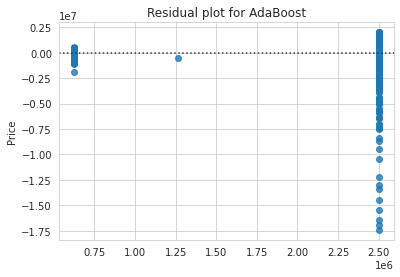

In [ ]:
# Residual Plot for AdaBoost
sns.residplot(final_predictions2, (final_predictions2 - y_test))
plt.title('Residual plot for AdaBoost')

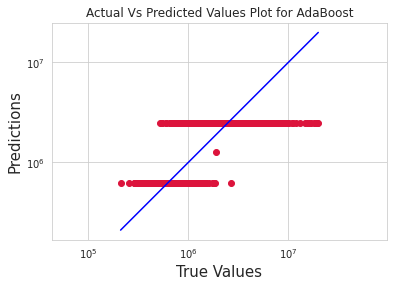

In [ ]:
# Actual vs Predicted Plot for AdaBoost
plt.scatter(y_test, final_predictions2, c='crimson')
plt.yscale('log')
plt.xscale('log')

p1 = max(max(final_predictions2), max(y_test))
p2 = min(min(final_predictions2), min(y_test))
plt.plot([p1, p2], [p1, p2], 'b-')
plt.xlabel('True Values', fontsize=15)
plt.ylabel('Predictions', fontsize=15)
plt.axis('equal')
plt.title("Actual Vs Predicted Values Plot for AdaBoost")
plt.show()

### LightBGM

In [ ]:
# creating a DecisionTreeClassifier Instance and fitting
import lightgbm as lgb
clf = lgb.LGBMClassifier().fit(X_train, y_train)

In [ ]:
# Importimg DecisionTreeClassifier from sklearn.tree
# creating a DecisionTreeClassifier Instance and fitting
final_predictions2 = clf.predict(X_test)
rmse1 = mean_squared_error(y_test, final_predictions2, squared=False)
print('Testing RMSE:', round(rmse1, 2))# Root Mean Squared error for lightgbm
print(r2_score(y_test, final_predictions2))# R2 score for lightgbm
print(mean_absolute_error(y_test, final_predictions2))# Mean Absolute error for lightgbm
print(mean_squared_error(y_test, final_predictions2))# Mean squared error for lightgbm

Testing RMSE: 1884690.16
0.19520590151461914
691983.1279373368
3552057003390.089


Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.


Text(0.5, 1.0, 'Residual plot for LightBGM')

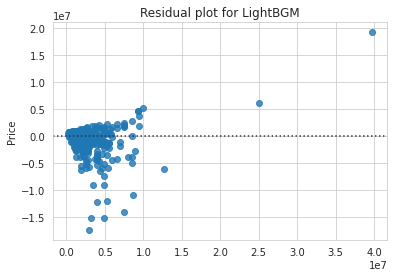

In [ ]:
# Residual Plot for lightgbm
sns.residplot(final_predictions2, (final_predictions2 - y_test))
plt.title('Residual plot for LightBGM')

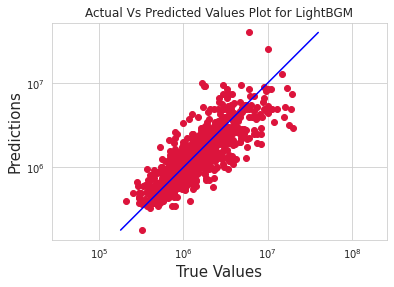

In [ ]:
# Actual vs Predicted Plot for lightgbm
plt.scatter(y_test, final_predictions2, c='crimson')
plt.yscale('log')
plt.xscale('log')

p1 = max(max(final_predictions2), max(y_test))
p2 = min(min(final_predictions2), min(y_test))
plt.plot([p1, p2], [p1, p2], 'b-')
plt.xlabel('True Values', fontsize=15)
plt.ylabel('Predictions', fontsize=15)
plt.axis('equal')
plt.title("Actual Vs Predicted Values Plot for LightBGM")
plt.show()

### SVM

In [ ]:
# creating a SVC Instance and fitting
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
clf = make_pipeline(StandardScaler(), SVC(gamma='auto')).fit(X_train, y_train)

In [ ]:
final_predictions2 = clf.predict(X_test)
rmse1 = mean_squared_error(y_test, final_predictions2, squared=False)
print('Testing RMSE:', round(rmse1, 2))# Root Mean Squared error for svm
print(r2_score(y_test, final_predictions2))# R2 score for svm
print(mean_absolute_error(y_test, final_predictions2))# Mean Absolute error for svm
print(mean_squared_error(y_test, final_predictions2))# Mean squared error for svm

Testing RMSE: 1896937.04
0.1847126741602414
812489.2880765883
3598370143337.845


Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.


Text(0.5, 1.0, 'Residual plot for SVM')

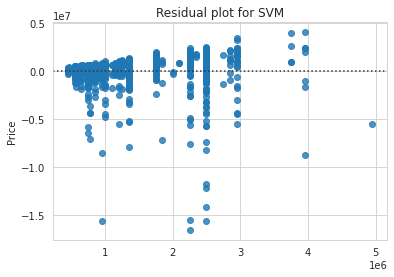

In [ ]:
# Residual Plot for svm
sns.residplot(final_predictions2, (final_predictions2 - y_test))
plt.title('Residual plot for SVM')

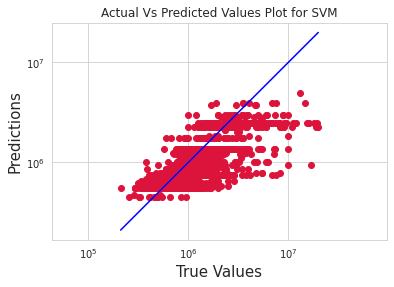

In [ ]:
# Actual vs Predicted Plot for svm
plt.scatter(y_test, final_predictions2, c='crimson')
plt.yscale('log')
plt.xscale('log')

p1 = max(max(final_predictions2), max(y_test))
p2 = min(min(final_predictions2), min(y_test))
plt.plot([p1, p2], [p1, p2], 'b-')
plt.xlabel('True Values', fontsize=15)
plt.ylabel('Predictions', fontsize=15)
plt.axis('equal')
plt.title("Actual Vs Predicted Values Plot for SVM")
plt.show()

### KNN

In [ ]:
# Importimg KNeighborsClassifier from klearn.neighbors
# creating a KNN Instance and fitting
from sklearn.neighbors import KNeighborsClassifier
clf = KNeighborsClassifier(n_neighbors=2).fit(X_train, y_train)

In [ ]:
final_predictions2 = clf.predict(X_test)
rmse1 = mean_squared_error(y_test, final_predictions2, squared=False)
print('Testing RMSE:', round(rmse1, 2))# Root Mean Squared error for  KNN 
print(r2_score(y_test, final_predictions2))# R2 score for  KNN 
print(mean_absolute_error(y_test, final_predictions2))# Mean Absolute error for  KNN 
print(mean_squared_error(y_test, final_predictions2))# Mean squared error for  KNN 

Testing RMSE: 1638606.67
0.39164890361205196
694107.0826805918
2685031831758.7695


Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.


Text(0.5, 1.0, 'Residual plot for KNN')

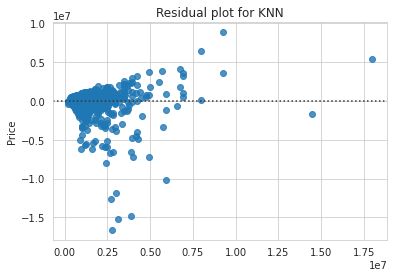

In [ ]:
# Residual Plot for  KNN 
from seaborn.regression import residplot
sns.residplot(final_predictions2, (final_predictions2 - y_test))
plt.title('Residual plot for KNN')

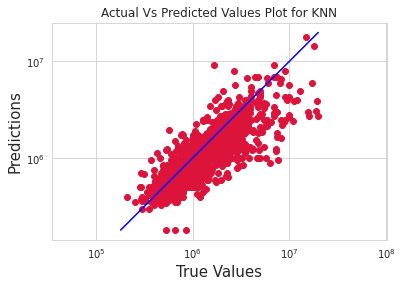

In [ ]:
# Actual vs Predicted Plot for  KNN 
plt.scatter(y_test, final_predictions2, c='crimson')
plt.yscale('log')
plt.xscale('log')

p1 = max(max(final_predictions2), max(y_test))
p2 = min(min(final_predictions2), min(y_test))
plt.plot([p1, p2], [p1, p2], 'b-')
plt.xlabel('True Values', fontsize=15)
plt.ylabel('Predictions', fontsize=15)
plt.axis('equal')
plt.title("Actual Vs Predicted Values Plot for KNN")
plt.show()

## Insights:
    - The models with a higher r2 score are considered to be well-performed
    - XGBoost has a lower RMSE and greater r2 than the other regression models. On this dataset, XGBoost outperforms other models.
    
    

In [ ]:
## ANN Model
import tensorflow as tf

from keras.models import Sequential
from keras.layers import Dense, Activation, Flatten, Dropout, BatchNormalization
from keras.optimizers import RMSprop,Adam
from keras.callbacks import ReduceLROnPlateau

NN_model = Sequential()

# The Input Layer :
NN_model.add(Dense(324, kernel_initializer='normal',input_dim = X_train.shape[1], activation='relu'))

# The Hidden Layers :
NN_model.add(Dense(512, activation='relu'))
NN_model.add(Dense(1024, activation='relu'))
NN_model.add(Dense(1024, activation='relu'))
NN_model.add(Dense(512, activation='relu'))
NN_model.add(Dense(256, activation='relu'))


NN_model.add(Flatten())


NN_model.add(Dense(4096, activation='relu'))
NN_model.add(Dropout(0.5))

NN_model.add(Dense(4096, activation='relu'))
NN_model.add(Dropout(0.5))

# The Output Layer :
NN_model.add(Dense(1, kernel_initializer='normal',activation='linear', kernel_regularizer = tf.keras.regularizers.l1(l=0.01) ))

optimizer=Adam(learning_rate=0.01, beta_1=0.9, beta_2=0.999)

# Compile the network :
NN_model.compile(optimizer=optimizer, loss='mean_absolute_error', metrics=['mean_absolute_error'])
NN_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 324)               2268      
                                                                 
 dense_1 (Dense)             (None, 512)               166400    
                                                                 
 dense_2 (Dense)             (None, 1024)              525312    
                                                                 
 dense_3 (Dense)             (None, 1024)              1049600   
                                                                 
 dense_4 (Dense)             (None, 512)               524800    
                                                                 
 dense_5 (Dense)             (None, 256)               131328    
                                                                 
 flatten (Flatten)           (None, 256)               0

In [ ]:
#Model fitting
NN_model.fit(x=X_train,y=y_train,
          validation_data=(X_train, y_train),
          batch_size=128,epochs=20)

Epoch 1/20
19/19 [==============================] - 19s 933ms/step - loss: 2574108.2500 - mean_absolute_error: 2574106.5000 - val_loss: 1219089.2500 - val_mean_absolute_error: 1219088.2500
Epoch 2/20
19/19 [==============================] - 19s 1s/step - loss: 883986.0000 - mean_absolute_error: 883984.9375 - val_loss: 985498.0000 - val_mean_absolute_error: 985496.8750
Epoch 3/20
19/19 [==============================] - 17s 907ms/step - loss: 809220.3125 - mean_absolute_error: 809219.4375 - val_loss: 757527.6875 - val_mean_absolute_error: 757526.8750
Epoch 4/20
19/19 [==============================] - 15s 828ms/step - loss: 739251.3750 - mean_absolute_error: 739250.4375 - val_loss: 698053.1875 - val_mean_absolute_error: 698052.4375
Epoch 5/20
19/19 [==============================] - 15s 814ms/step - loss: 730984.8125 - mean_absolute_error: 730984.0000 - val_loss: 726727.2500 - val_mean_absolute_error: 726726.5625
Epoch 6/20
19/19 [==============================] - 16s 830ms/step - loss:

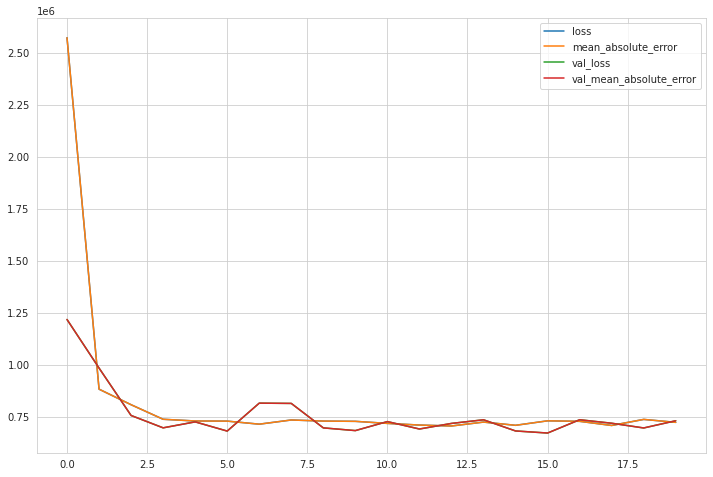

In [ ]:
# ploting loss graph for ANN
loss_df = pd.DataFrame(NN_model.history.history)
loss_df.plot(figsize=(12,8))

36/36 [==============================] - 2s 49ms/step
MAE: 746336.7551403394
MSE: 3020618463140.24
RMSE: 1737992.653361987
VarScore: 0.315614611310821


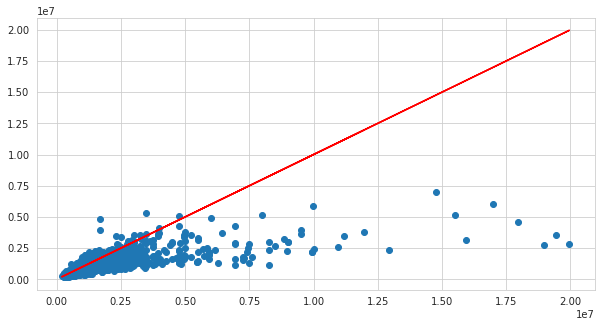

In [ ]:
y_pred = NN_model.predict(X_test)
from sklearn import metrics
print('MAE:', metrics.mean_absolute_error(y_test, y_pred))  
print('MSE:', metrics.mean_squared_error(y_test, y_pred))  
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print('VarScore:',metrics.r2_score(y_test,y_pred))
# Visualizing Our predictions
fig = plt.figure(figsize=(10,5))
plt.scatter(y_test,y_pred)
# Perfect predictions
plt.plot(y_test,y_test,'r')

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, LSTM

# Build the LSTM model
LSTM_model = Sequential()
LSTM_model.add(LSTM(128, return_sequences=True, input_shape= (X_train.shape[1], 1)))
LSTM_model.add(LSTM(64, return_sequences=False))
LSTM_model.add(Dense(25))
LSTM_model.add(Dense(1))

# Compile the model
LSTM_model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
LSTM_model.fit(X_train, y_train, batch_size=128, epochs=600)

Epoch 1/600
19/19 [==============================] - 5s 34ms/step - loss: 9004411518976.0000
Epoch 2/600
19/19 [==============================] - 1s 34ms/step - loss: 9004363284480.0000
Epoch 3/600
19/19 [==============================] - 1s 35ms/step - loss: 9004309807104.0000
Epoch 4/600
19/19 [==============================] - 1s 37ms/step - loss: 9004256329728.0000
Epoch 5/600
19/19 [==============================] - 1s 36ms/step - loss: 9004192366592.0000
Epoch 6/600
19/19 [==============================] - 1s 35ms/step - loss: 9004118966272.0000
Epoch 7/600
19/19 [==============================] - 1s 37ms/step - loss: 9004038225920.0000
Epoch 8/600
19/19 [==============================] - 1s 36ms/step - loss: 9003946999808.0000
Epoch 9/600
19/19 [==============================] - 1s 38ms/step - loss: 9003843190784.0000
Epoch 10/600
19/19 [==============================] - 1s 36ms/step - loss: 9003730993152.0000
Epoch 11/600
19/19 [==============================] - 1s 36ms/step - 

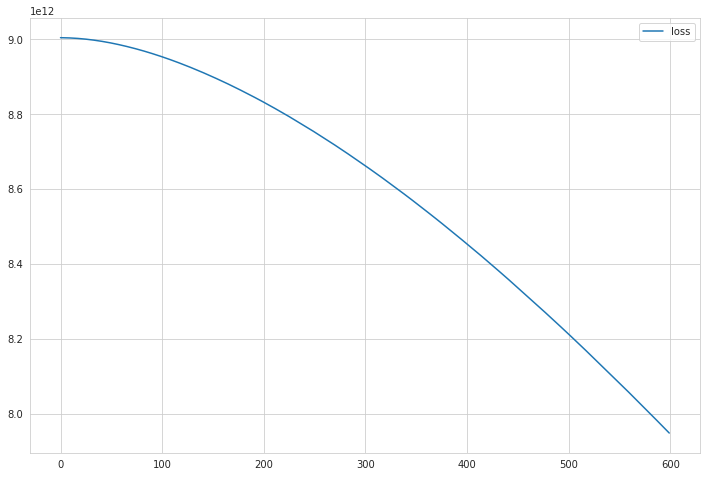

In [ ]:
# plotting loss graph fpr LSTM
loss_df = pd.DataFrame(LSTM_model.history.history)
loss_df.plot(figsize=(12,8))

36/36 [==============================] - 1s 7ms/step
MAE: 1539287.2103731507
MSE: 6781755442183.772
RMSE: 2604180.3781965203
VarScore: -0.5365510046802655


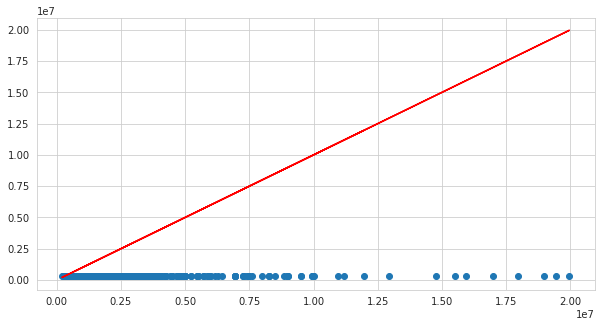

In [ ]:
y_pred = LSTM_model.predict(X_test)
from sklearn import metrics
print('MAE:', metrics.mean_absolute_error(y_test, y_pred))  
print('MSE:', metrics.mean_squared_error(y_test, y_pred))  
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print('VarScore:',metrics.r2_score(y_test,y_pred))
# Visualizing Our predictions
fig = plt.figure(figsize=(10,5))
plt.scatter(y_test,y_pred)
# Perfect predictions
plt.plot(y_test,y_test,'r')

## Insights:
    - The LSTM model is given a total of 600 training iterations (epochs). Scores for RMSE, MAE, MSE, and R2 were calculated.
    - The R2 score becomes lower, or gets closer to zero, as the number of epochs used in the analysis is higher.
    - The graphic shows that the model's performance is more stable and that ANN model residual cumulative values improve gradually with sample data.

In [ ]:
! pip install eli5

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 216 kB 7.1 MB/s 
     |████████████████████████████████| 133 kB 52.3 MB/s 
  Created wheel for eli5: filename=eli5-0.13.0-py2.py3-none-any.whl size=107748 sha256=712734f3b974e69d53068da728db459fd74e96cb58700a04b9cbb90bf97b8feb
  Stored in directory: /root/.cache/pip/wheels/85/ac/25/ffcd87ef8f9b1eec324fdf339359be71f22612459d8c75d89c
Successfully built eli5
  Attempting uninstall: jinja2
    Found existing installation: Jinja2 2.11.3
    Uninstalling Jinja2-2.11.3:
      Successfully uninstalled Jinja2-2.11.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
notebook 5.7.16 requires jinja2<=3.0.0, but you have jinja2 3.1.2 which is incompatible.
flask 1.1.4 requires Jinja2<3.0,>=2.10.1, but you have jinja2 3.1.2 which is incompa

In [ ]:
! pip install dalex

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 1.0 MB 6.4 MB/s 
  Created wheel for dalex: filename=dalex-1.5.0-py3-none-any.whl size=1043321 sha256=a40f7bed11142289318d8be2a16c7e9d5207020dcd587ef2386fa444ca4afae4
  Stored in directory: /root/.cache/pip/wheels/b1/02/58/77ac4cb307fec9f3324c6aa4f9f23a7b0e886e313ebc280257
Successfully built dalex


In [ ]:
! pip install flask_cors

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 125 kB 6.5 MB/s 
  Attempting uninstall: Jinja2
    Found existing installation: Jinja2 3.1.2
    Uninstalling Jinja2-3.1.2:
      Successfully uninstalled Jinja2-3.1.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
eli5 0.13.0 requires jinja2>=3.0.0, but you have jinja2 2.11.3 which is incompatible.


In [ ]:
! pip install datatable 

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 96.6 MB 64 kB/s 


In [ ]:
! pip install Flask==2.1.0

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 95 kB 2.7 MB/s 
     |████████████████████████████████| 232 kB 51.8 MB/s 
     |████████████████████████████████| 96 kB 691 kB/s 
  Using cached Jinja2-3.1.2-py3-none-any.whl (133 kB)
  Attempting uninstall: MarkupSafe
    Found existing installation: MarkupSafe 2.0.1
    Uninstalling MarkupSafe-2.0.1:
      Successfully uninstalled MarkupSafe-2.0.1
  Attempting uninstall: Werkzeug
    Found existing installation: Werkzeug 1.0.1
    Uninstalling Werkzeug-1.0.1:
      Successfully uninstalled Werkzeug-1.0.1
  Attempting uninstall: Jinja2
    Found existing installation: Jinja2 2.11.3
    Uninstalling Jinja2-2.11.3:
      Successfully uninstalled Jinja2-2.11.3
  Attempting uninstall: itsdangerous
    Found existing installation: itsdangerous 1.1.0
    Uninstalling itsdangerous-1.1.0:
      Successfully uninstalled itsdangerous-1.1.0
  Attempting unins

In [ ]:
! pip install lime

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 275 kB 5.8 MB/s 
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283857 sha256=341c71d08ee830a17c06475f1b0f76a40eeb9ea1741b83e9e019c09eff95a40d
  Stored in directory: /root/.cache/pip/wheels/e6/a6/20/cc1e293fcdb67ede666fed293cb895395e7ecceb4467779546
Successfully built lime


In [ ]:
import numpy as np
import pandas as pd
import xgboost as xgb
import dalex as dx
import datatable as dt # data table factory
from sklearn.metrics import f1_score,confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import shap
import ipywidgets
from ipywidgets import IntProgress
import statsmodels
import lime
import warnings
import flask
import flask_cors

In [ ]:
explainer = dx.Explainer(lin_reg,X_train,y_train) # create explainer from Dalex

Preparation of a new explainer is initiated

  -> data              : 2331 rows 6 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 2331 values
  -> model_class       : sklearn.linear_model._base.LinearRegression (default)
  -> label             : Not specified, model's class short name will be used. (default)
  -> predict function  : <function yhat_default at 0x7f6ed90abf70> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = -4.82e+05, mean = 1.87e+06, max = 2.02e+07
  -> model type        : regression will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -8.78e+06, mean = -1.29e-10, max = 3.2e+07
  -> model_info        : package sklearn

A new explainer has been created!


X does not have valid feature names, but LinearRegression was fitted with feature names


In [ ]:
# Generate importance plot showing top 30
explainer.model_parts().plot(max_vars=30)

In [ ]:
# Generate residual plots
explainer.model_performance(model_type = 'regression').plot()

In [ ]:
# Generate PDP plots for all variables 
explainer.model_profile(type = 'partial', label="pdp").plot()

Calculating ceteris paribus: 100%|██████████| 6/6 [00:00<00:00, 94.16it/s]


In [ ]:
# Generate Accumulated Local Effects plots for all variables 
explainer.model_profile(type = 'ale', label="pdp").plot()

Calculating accumulated dependency: 100%|██████████| 6/6 [00:00<00:00,  8.30it/s]


In [ ]:
# Generate Individual Conditional Expectation plots for worst texture variable 
explainer.model_profile(type = 'conditional', label="conditional",variables="Area in sq ft")

Calculating conditional dependency: 100%|██████████| 1/1 [00:00<00:00, 14.78it/s]


,_vname_,_label_,_x_,_yhat_,_ids_
0,Area in sq ft,conditional,292.00,-1.133942e+05,0
1,Area in sq ft,conditional,443.13,9.774182e+04,0
2,Area in sq ft,conditional,594.26,3.088196e+05,0
3,Area in sq ft,conditional,745.39,5.198379e+05,0
4,Area in sq ft,conditional,896.52,7.307956e+05,0
...,...,...,...,...,...
96,Area in sq ft,conditional,14800.48,1.901135e+07,0
97,Area in sq ft,conditional,14951.61,1.918851e+07,0
98,Area in sq ft,conditional,15102.74,1.936628e+07,0
99,Area in sq ft,conditional,15253.87,1.954475e+07,0


In [ ]:
! pip install --upgrade category_encoders

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 72 kB 690 kB/s 


In [ ]:
! pip install shapash

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 917 kB 10.0 MB/s 
     |████████████████████████████████| 642 kB 56.4 MB/s 
     |████████████████████████████████| 1.0 MB 55.1 MB/s 
     |████████████████████████████████| 220 kB 42.2 MB/s 
     |████████████████████████████████| 9.9 MB 53.0 MB/s 
  Created wheel for dash-renderer: filename=dash_renderer-1.8.3-py3-none-any.whl size=1013943 sha256=ded487512e05b51d98e22d01458a5a2585bf5bc72db5cd00b27228be42770789
  Stored in directory: /root/.cache/pip/wheels/82/4d/8c/0764de014b25313cf54199f212bad4fb4b228ecfaef58be3b9
  Created wheel for dash-daq: filename=dash_daq-0.5.0-py3-none-any.whl size=669715 sha256=717cdfb971187287f7dec7b95345a1c69a1395be5c38218c8f167c4752d276e8
  Stored in directory: /root/.cache/pip/wheels/00/35/e5/57e90f10c529601c6627400513cb65dd5adb09752411f5a050
Successfully built dash-renderer dash-daq


In [ ]:
from yellowbrick.datasets import load_concrete
from yellowbrick.regressor import ResidualsPlot

/usr/local/lib/python3.8/dist-packages/sklearn/base.py:450: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



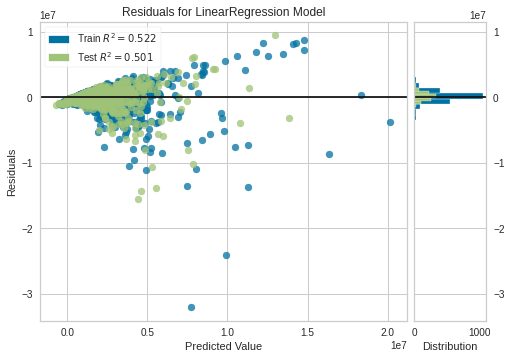

In [ ]:
# Plotting the Residual plot using yellowbrick 
visualizer = ResidualsPlot(lin_reg)

visualizer.fit(X_train, y_train)  # Fit the training data to the visualizer
visualizer.score(X_test, y_test)  # Evaluate the model on the test data
visualizer.show() 

/usr/local/lib/python3.8/dist-packages/sklearn/base.py:450: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



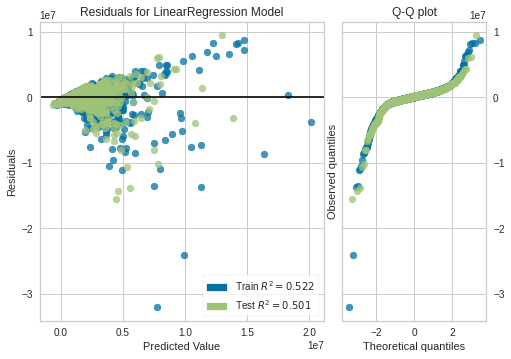

In [ ]:
visualizer = ResidualsPlot(lin_reg, hist=False, qqplot=True)
visualizer.fit(X_train, y_train)
visualizer.score(X_test, y_test)
visualizer.show()

/usr/local/lib/python3.8/dist-packages/sklearn/base.py:450: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



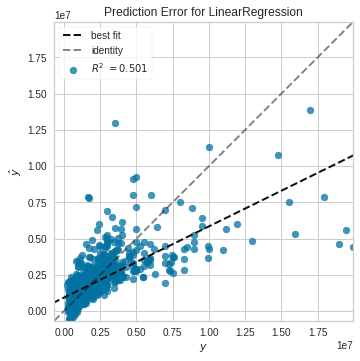

In [ ]:
# Prediction error plot for Linear Regression using yellowbrick
from yellowbrick.regressor import PredictionError
visualizer = PredictionError(lin_reg)
visualizer.fit(X_train, y_train)  # Fit the training data to the visualizer
visualizer.score(X_test, y_test)  # Evaluate the model on the test data
visualizer.show()                 # Finalize and render the figure